# Naive Bayes + Decision Trees (BoW)

Training the two BoW-based classifiers. Seven decades × two models = 14 models total.

Loads the balanced dataframes from the BoW setup notebook. Using `balanced_2000_df` as the main dataset.

Metrics: accuracy + F1

## Load data

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [ ]:
# loading the CSV from BoW setup notebook
# if running fresh in Colab, upload balanced_2000_df.csv first
balanced_2000_df = pd.read_csv('balanced_2000_df.csv')

print(f'Loaded: {len(balanced_2000_df):,} rows')
print(f'Columns: {balanced_2000_df.columns.tolist()}')
print(f'Decades: {sorted(balanced_2000_df["decade"].unique())}')
print(f'Hit rate: {balanced_2000_df["is_hit"].mean():.1%}')

Loaded: 14,000 rows
Columns: ['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']
Decades: ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
Hit rate: 20.0%


## Sanity check on pooled data

Running both models on all decades pooled first, before doing the per-decade split. Mainly to confirm the pipeline works and get a baseline number to compare against.

80/20 split, stratified by `is_hit` so both train and test keep the 20% hit rate.

In [ ]:
df = balanced_2000_df[['lyrics', 'is_hit']].dropna(subset=['lyrics']).copy()
print(f'Rows after dropping null lyrics: {len(df):,}')

X = df['lyrics'].astype(str).values
y = df['is_hit'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# fit vectorizer on train only so test vocab doesn't leak
vectorizer = CountVectorizer(
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2)
)
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow  = vectorizer.transform(X_test)
print(f'Vocabulary size: {len(vectorizer.vocabulary_):,}')
print(f'Train matrix: {X_train_bow.shape}, Test matrix: {X_test_bow.shape}')

# NB
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
nb_pred = nb.predict(X_test_bow)
print(f'\n--- Naive Bayes (pooled) ---')
print(f'Accuracy: {accuracy_score(y_test, nb_pred):.3f}')
print(f'F1:       {f1_score(y_test, nb_pred):.3f}')
print(classification_report(y_test, nb_pred, target_names=['non-hit', 'hit']))

# DT
dt = DecisionTreeClassifier(max_depth=20, random_state=42)
dt.fit(X_train_bow, y_train)
dt_pred = dt.predict(X_test_bow)
print(f'--- Decision Tree (pooled) ---')
print(f'Accuracy: {accuracy_score(y_test, dt_pred):.3f}')
print(f'F1:       {f1_score(y_test, dt_pred):.3f}')
print(classification_report(y_test, dt_pred, target_names=['non-hit', 'hit']))

Rows after dropping null lyrics: 14,000
Vocabulary size: 118,352
Train matrix: (11200, 118352), Test matrix: (2800, 118352)

--- Naive Bayes (pooled) ---
Accuracy: 0.874
F1:       0.650
              precision    recall  f1-score   support

     non-hit       0.90      0.95      0.92      2240
         hit       0.73      0.59      0.65       560

    accuracy                           0.87      2800
   macro avg       0.81      0.77      0.79      2800
weighted avg       0.87      0.87      0.87      2800

--- Decision Tree (pooled) ---
Accuracy: 0.832
F1:       0.440
              precision    recall  f1-score   support

     non-hit       0.85      0.96      0.90      2240
         hit       0.66      0.33      0.44       560

    accuracy                           0.83      2800
   macro avg       0.75      0.64      0.67      2800
weighted avg       0.81      0.83      0.81      2800



## Per-decade training — 14 models

Looping through each decade and training both models separately. Each decade gets its own vectorizer since the vocab is pretty different between eras.

- **Naive Bayes** — standard BoW baseline, fast and interpretable
- **Decision Tree** — `max_depth=20` so it doesn't overfit on the sparse text features

In [ ]:
results = {}
results_rows = []  # long format for pivoting later

for decade, group in balanced_2000_df.groupby('decade'):
    print(f'\n========== {decade} ==========')

    df = group[['lyrics', 'is_hit']].dropna(subset=['lyrics']).copy()
    if len(df) < 50 or df['is_hit'].nunique() < 2:
        print(f'Skipping {decade} — not enough data or only one class')
        continue

    X = df['lyrics'].astype(str).values
    y = df['is_hit'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    vectorizer = CountVectorizer(
        stop_words='english',
        min_df=2,
        ngram_range=(1, 2)
    )
    X_train_bow = vectorizer.fit_transform(X_train)
    X_test_bow  = vectorizer.transform(X_test)
    vocab_size = len(vectorizer.vocabulary_)

    # NB
    nb = MultinomialNB()
    nb.fit(X_train_bow, y_train)
    nb_pred = nb.predict(X_test_bow)
    nb_acc = accuracy_score(y_test, nb_pred)
    nb_f1  = f1_score(y_test, nb_pred)

    # DT
    dt = DecisionTreeClassifier(max_depth=20, random_state=42)
    dt.fit(X_train_bow, y_train)
    dt_pred = dt.predict(X_test_bow)
    dt_acc = accuracy_score(y_test, dt_pred)
    dt_f1  = f1_score(y_test, dt_pred)

    results[decade] = {
        'nb_accuracy': nb_acc, 'nb_f1': nb_f1,
        'dt_accuracy': dt_acc, 'dt_f1': dt_f1,
    }
    print(f'NB  → accuracy={nb_acc:.3f}, f1={nb_f1:.3f}')
    print(f'DT  → accuracy={dt_acc:.3f}, f1={dt_f1:.3f}')

    results_rows.append({'decade': decade, 'model': 'NaiveBayes',   'accuracy': nb_acc, 'f1': nb_f1})
    results_rows.append({'decade': decade, 'model': 'DecisionTree', 'accuracy': dt_acc, 'f1': dt_f1})

results_df = pd.DataFrame(results_rows)

print('\n===== All Decade Results =====')
for decade, m in results.items():
    print(f"{decade}: NB acc={m['nb_accuracy']:.3f}, f1={m['nb_f1']:.3f} | DT acc={m['dt_accuracy']:.3f}, f1={m['dt_f1']:.3f}")


========== 1960s ==========
NB  → accuracy=0.820, f1=0.463
DT  → accuracy=0.823, f1=0.336

========== 1970s ==========
NB  → accuracy=0.807, f1=0.374
DT  → accuracy=0.782, f1=0.365

========== 1980s ==========
NB  → accuracy=0.800, f1=0.365
DT  → accuracy=0.797, f1=0.283

========== 1990s ==========
NB  → accuracy=0.818, f1=0.517
DT  → accuracy=0.785, f1=0.442

========== 2000s ==========
NB  → accuracy=0.802, f1=0.378
DT  → accuracy=0.780, f1=0.389

========== 2010s ==========
NB  → accuracy=0.848, f1=0.512
DT  → accuracy=0.782, f1=0.365

========== 2020s ==========
NB  → accuracy=0.868, f1=0.613
DT  → accuracy=0.853, f1=0.563

===== All Decade Results =====
1960s: NB acc=0.820, f1=0.463 | DT acc=0.823, f1=0.336
1970s: NB acc=0.807, f1=0.374 | DT acc=0.782, f1=0.365
1980s: NB acc=0.800, f1=0.365 | DT acc=0.797, f1=0.283
1990s: NB acc=0.818, f1=0.517 | DT acc=0.785, f1=0.442
2000s: NB acc=0.802, f1=0.378 | DT acc=0.780, f1=0.389
2010s: NB acc=0.848, f1=0.512 | DT acc=0.782, f1=0.365
2

## Evaluation

Accuracy + F1 per decade for both models, plus a chart to see how performance changes over time.

In [ ]:
# side-by-side comparison of NB vs DT

pivot_acc = results_df.pivot(index='decade', columns='model', values='accuracy').round(3)
pivot_f1  = results_df.pivot(index='decade', columns='model', values='f1').round(3)

print('=== Accuracy ===')
print(pivot_acc.to_string())
print('\n=== F1 ===')
print(pivot_f1.to_string())

=== Accuracy ===
model   DecisionTree  NaiveBayes
decade                          
1960s          0.822       0.820
1970s          0.782       0.808
1980s          0.798       0.800
1990s          0.785       0.818
2000s          0.780       0.802
2010s          0.782       0.848
2020s          0.852       0.868

=== F1 ===
model   DecisionTree  NaiveBayes
decade                          
1960s          0.336       0.463
1970s          0.365       0.374
1980s          0.283       0.365
1990s          0.442       0.517
2000s          0.389       0.378
2010s          0.365       0.512
2020s          0.563       0.613


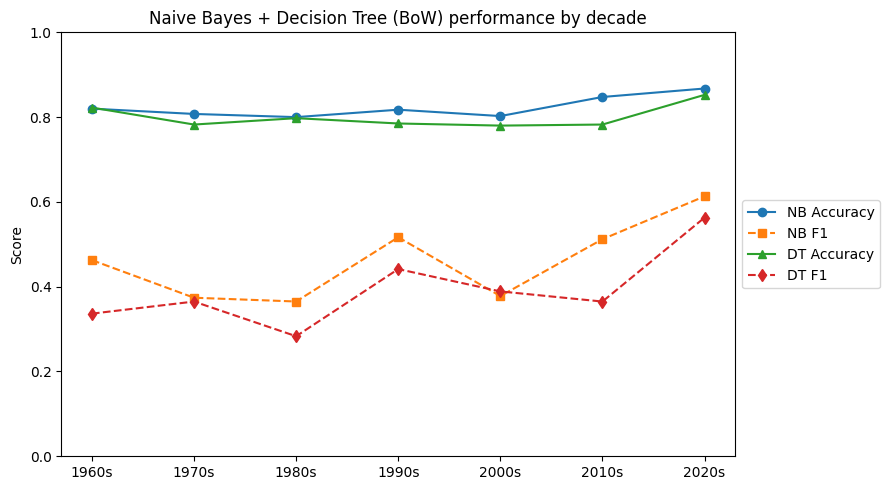

In [ ]:
# performance by decade

import matplotlib.pyplot as plt

decades     = list(results.keys())
nb_accuracy = [results[d]['nb_accuracy'] for d in decades]
nb_f1       = [results[d]['nb_f1']       for d in decades]
dt_accuracy = [results[d]['dt_accuracy'] for d in decades]
dt_f1       = [results[d]['dt_f1']       for d in decades]

plt.figure(figsize=(9, 5))
plt.plot(decades, nb_accuracy, marker='o', label='NB Accuracy')
plt.plot(decades, nb_f1,       marker='s', linestyle='--', label='NB F1')
plt.plot(decades, dt_accuracy, marker='^', label='DT Accuracy')
plt.plot(decades, dt_f1,       marker='d', linestyle='--', label='DT F1')
plt.ylim(0.0, 1.0)
plt.ylabel('Score')
plt.title('Naive Bayes + Decision Tree (BoW) performance by decade')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [ ]:
# save results for presentation comparison

results_df.to_csv('bow_nb_dt_results.csv', index=False)
print('Saved: bow_nb_dt_results.csv')
print(results_df)

Saved: bow_nb_dt_results.csv
   decade         model  accuracy        f1
0   1960s    NaiveBayes    0.8200  0.462687
1   1960s  DecisionTree    0.8225  0.336449
2   1970s    NaiveBayes    0.8075  0.373984
3   1970s  DecisionTree    0.7825  0.364964
4   1980s    NaiveBayes    0.8000  0.365079
5   1980s  DecisionTree    0.7975  0.283186
6   1990s    NaiveBayes    0.8175  0.516556
7   1990s  DecisionTree    0.7850  0.441558
8   2000s    NaiveBayes    0.8025  0.377953
9   2000s  DecisionTree    0.7800  0.388889
10  2010s    NaiveBayes    0.8475  0.512000
11  2010s  DecisionTree    0.7825  0.364964
12  2020s    NaiveBayes    0.8675  0.613139
13  2020s  DecisionTree    0.8525  0.562963


In [ ]:
# Top 10 DISTINCTIVE words per decade in hit songs

from collections import Counter

print("=" * 70)
print("TOP 10 DISTINCTIVE WORDS IN HITS — UNIQUE TO EACH DECADE")
print("=" * 70)

decade_word_freq = {}

custom_stopwords = {
    'don', 'll', 've', 're', 's', 't', 'm', 'd',
    'aint', 'cant', 'wont', 'didnt', 'doesnt', 'gonna', 'gotta', 'wanna',
    'yeah', 'oh', 'ooh', 'ah', 'la', 'na', 'hey', 'uh', 'mm', 'whoa', 'ooo',
    'im', 'youre', 'its'
}

for decade, group in balanced_2000_df.groupby('decade'):
    hits_df = group[group['is_hit'] == 1]
    lyrics = hits_df['lyrics'].dropna().astype(str).values

    if len(lyrics) < 5:
        continue

    vectorizer = CountVectorizer(
        stop_words='english',
        min_df=2,
        ngram_range=(1, 1)
    )
    X = vectorizer.fit_transform(lyrics)
    vocab = vectorizer.get_feature_names_out()
    totals = np.asarray(X.sum(axis=0)).flatten()

    word_freq = {vocab[i]: totals[i] / totals.sum() for i in range(len(vocab))}
    decade_word_freq[decade] = word_freq

print("\n--- Distinctive words (high in this decade, low in others) ---")

distinctive_by_decade = {}

for target_decade in decade_word_freq:
    target_freq = decade_word_freq[target_decade]

    other_decades = [d for d in decade_word_freq if d != target_decade]

    scores = {}
    for word, freq_here in target_freq.items():
        if word in custom_stopwords or len(word) <= 2:
            continue

        other_freqs = [decade_word_freq[d].get(word, 0) for d in other_decades]
        avg_other = sum(other_freqs) / len(other_freqs) if other_freqs else 0

        score = freq_here / (avg_other + 1e-6)


        if freq_here < 0.0003:
            continue

        scores[word] = score

    top = sorted(scores.items(), key=lambda x: -x[1])[:10]
    top_words = [w for w, _ in top]
    distinctive_by_decade[target_decade] = top_words

    print(f"\n{target_decade}: {', '.join(top_words)}")

print("\n\n=== TABLE FOR SLIDES ===")
print(f"{'Decade':<8} | Distinctive words")
print("-" * 80)
for decade, words in distinctive_by_decade.items():
    print(f"{decade:<8} | {', '.join(words)}")

TOP 10 DISTINCTIVE WORDS IN HITS — UNIQUE TO EACH DECADE

--- Distinctive words (high in this decade, low in others) ---

1960s: shoo, boogety, ruby, jenny, bristol, jerk, wam, hoist, punch, mainsail

1970s: beep, toot, lola, tragedy, whooh, delivered, sealed, blaming, leroy, honky

1980s: roni, jammin, automatic, miracle, jessie, method, prerogative, laala, modern, centerfold

1990s: pump, doop, mow, waterloo, represent, felina, knockin, closes, boots, mysterious

2000s: legit, dem, mandy, ehh, thug, bottles, ella, hump, lumps, stabbers

2010s: gong, rebel, yuh, urgent, rump, grateful, humble, bitches, pickin, fuckin

2020s: rudolph, mum, rockabye, rocka, poker, mah, counting, whizzin, juda, judas


=== TABLE FOR SLIDES ===
Decade   | Distinctive words
--------------------------------------------------------------------------------
1960s    | shoo, boogety, ruby, jenny, bristol, jerk, wam, hoist, punch, mainsail
1970s    | beep, toot, lola, tragedy, whooh, delivered, sealed, blaming, 